In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
pd.set_option('display.max_columns',None)

In [30]:
url = 'https://raw.githubusercontent.com/ichiP245/my-next-soderling/refs/heads/main/Archivos/df_pre_enc.csv'
df = pd.read_csv(url)

In [31]:
df.loc[df['Location'] == 'Monte Carlo', 'Location'] = 'Monte Carlo, Monaco'

In [32]:
url_clima = 'https://raw.githubusercontent.com/ichiP245/my-next-soderling/refs/heads/main/Archivos/weatherATP.csv'
df_clima = pd.read_csv(url_clima)

In [33]:
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y-%m-%d')
df_clima['date'] = pd.to_datetime(df_clima['date'], format='%Y-%m-%d')

In [34]:
print(f'ANTES: Filas: df: {df.shape[0]}, columnas df: {df.shape[1]}')

df = df.merge(df_clima, left_on=['Fecha','Location'], right_on=['date','Ciudad'], how='inner')

print(f'DESPUES: Filas: df: {df.shape[0]}, columnas df: {df.shape[1]}')

ANTES: Filas: df: 16061, columnas df: 74
DESPUES: Filas: df: 16061, columnas df: 91


In [47]:
df = df.drop(columns=['date','Ciudad'])

Empezamos con un análisis univariado de variables categóricas y después pasamos directo al análisis de variables numéricas, que en la mayoría de los casos son variables que fueron creadas por mí. Por último, análisis bivariado y todos los análisis de la variable target.

## Análisis Categóricas

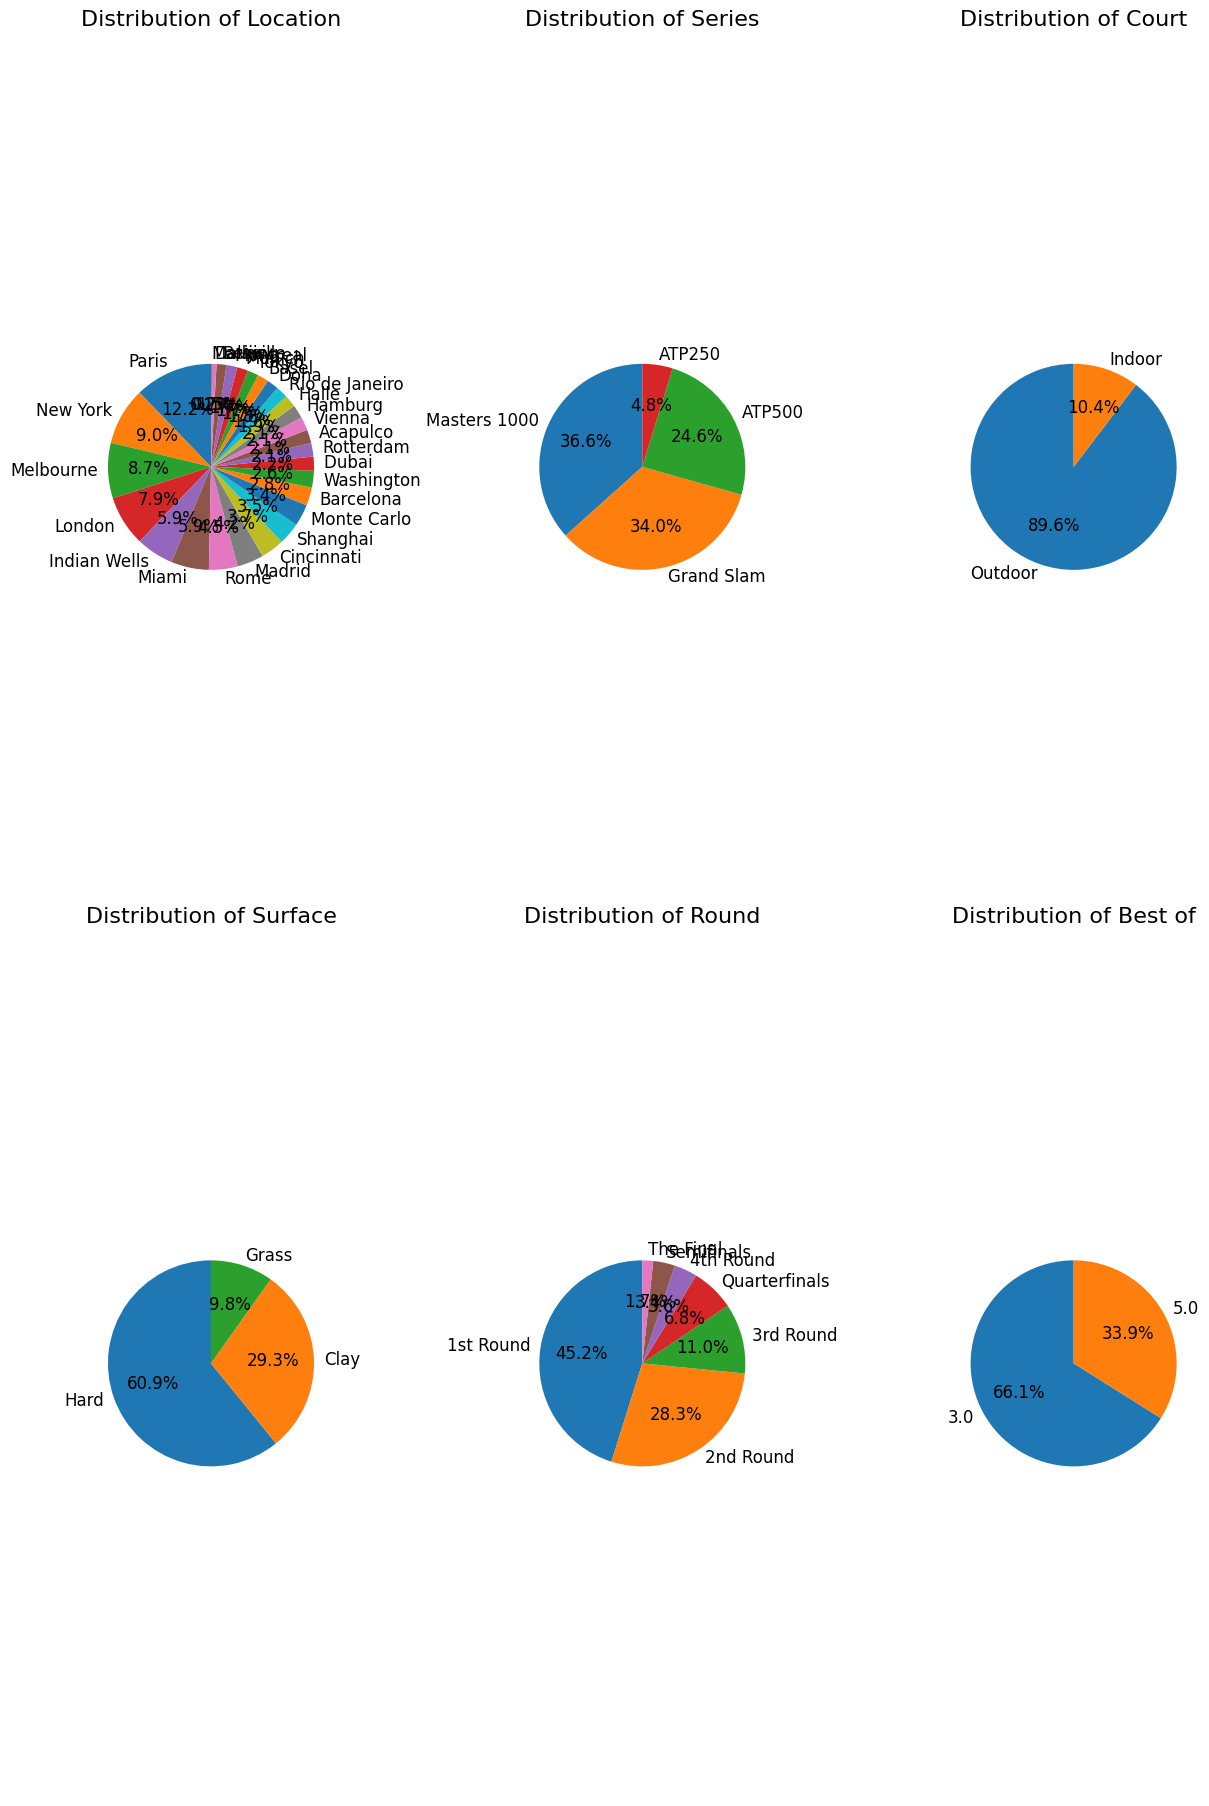

In [47]:
vars_cat = ['Location', 'Series', 'Court', 'Surface', 'Round', 'Best of']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12,18))
axes = axes.flatten()

for i, var in enumerate(vars_cat):
  axes[i].pie(df[var].value_counts(),
              labels=df[var].value_counts().index,
              autopct='%1.1f%%',
              startangle=90,
              textprops={'fontsize': 12})
  axes[i].set_title(f'Distribution of {var}', fontsize=16)
  axes[i].axis('equal')

# Hide any unused subplots
for j in range(len(vars_cat), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=0.5) # Reduced padding to bring titles closer
plt.show()

*Insights*:
- Las ciudades tiene más o menos la misma cantidad de partidos. Seguramente dependiendo de la cantidad de partidos del torneo hayan acumulado más o menos partidos a lo largo de los años que comprende el dataset
- Tenemos partidos de Grand Slam, Masters 1000 y ATP500 en proporciones similares. Pero de ATP250 no extrajimos datos, ¿cómo es eso posible?
- Casi siempre se juega afuera: el 90% de los partidos
- El pasto como superficie es inusual, algo que tiene mucho sentido si lo analizamos desde un punto de vista tenístico, y la superficie dura abunda como predominante
- Las primeras dos rondas son las que tienen más partidos: lógico, a medida que avanzan las rondas quedan menos participantes y por ende hay menos partidos
- La mayoría de partidos son a 3 sets. Esto tiene correlación intrínseca con el nivel del torneo

Observamos esta curiosidad. Cuando hicimos el scraping, scrapeamos a torneos ATP 500 o superior. Pero como extrajimos los últimos 10 años ocurrió que algunos torneos cambiaron de status (de ATP 250 subieron a ser ATP 500) hace menos tiempo entonces también se registran partidos de ese nivel. Los dejamos en la base.

In [48]:
df['Series'].value_counts()

,count
Series,
Masters 1000,5884
Grand Slam,5459
ATP500,3954
ATP250,764


In [49]:
# Ciudades que registran partidos de ATP250
df[df['Series'] == 'ATP250']['Location'].value_counts()

,count
Location,
Doha,263
Munich,243
Hamburg,119
Dallas,81
Vienna,31
Marseille,27


Comparamos la cantidad de partidos por ciudad

In [50]:
pd.DataFrame(df['Location'].value_counts()).T

Location,Paris,New York,Melbourne,London,Indian Wells,Miami,Rome,Madrid,Cincinnati,Shanghai,Monte Carlo,Barcelona,Washington,Dubai,Rotterdam,Acapulco,Vienna,Hamburg,Halle,Rio de Janeiro,Doha,Basel,Tokyo,Munich,Montreal,Beijing,Dallas,Marseille
count,1960,1451,1397,1270,950,950,724,670,590,560,548,454,423,355,341,341,341,336,310,304,294,279,279,274,273,248,112,27


## Análisis Numéricas

Variable ATP Ranking
- Distribución muy asimétrica a derecha

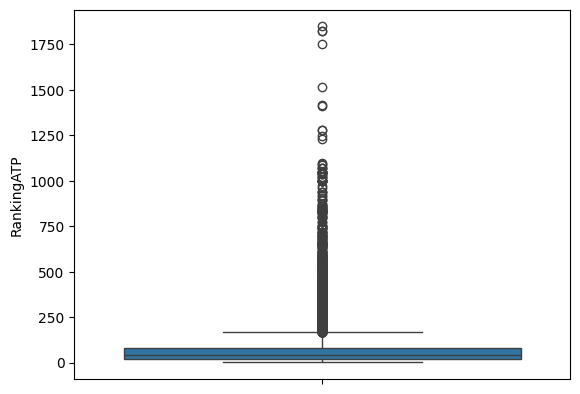

In [51]:
rankATP = pd.concat([df['rankA'], df['rankB']], axis=0).rename('RankingATP')
sns.boxplot(data=rankATP)
plt.show()

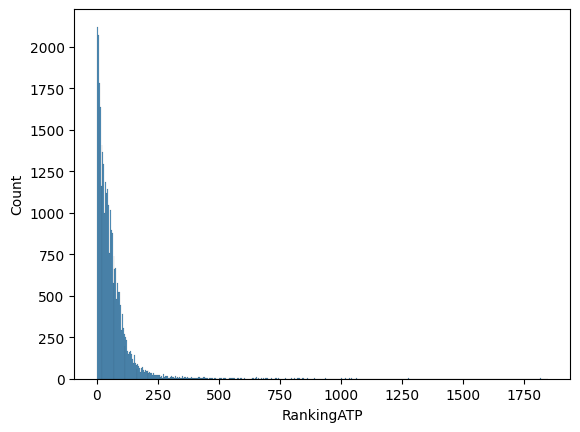

In [52]:
sns.histplot(rankATP)
plt.show()

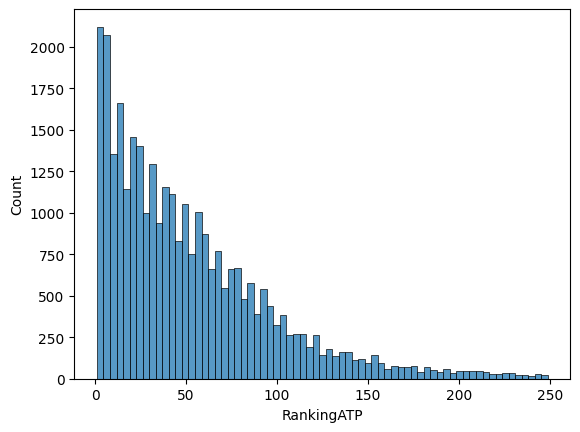

In [53]:
sns.histplot(rankATP[rankATP<250])
plt.show()

Variables relacionadas a Odds:

- Odds de B365 tienen mucha asimetría a derecha. Hay algunos outliers que podríamos ver de sacar

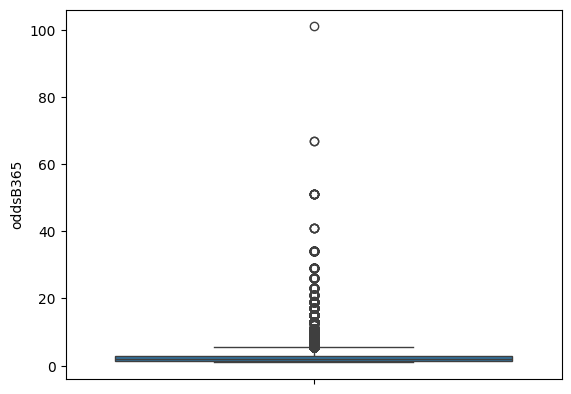

In [54]:
oddsB365 = pd.concat([df['B365A'], df['B365B']], axis=0).rename('oddsB365')
sns.boxplot(data=oddsB365)
plt.show()

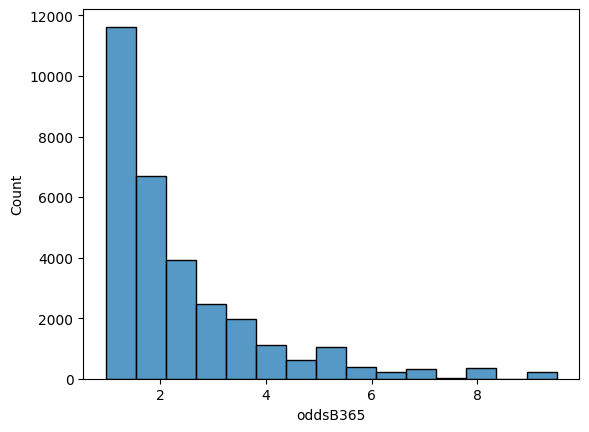

In [55]:
sns.histplot(oddsB365[oddsB365<10], bins=15)
plt.show()

In [56]:
# Vemos los partidos cuando hubo odds > 50 -> algunos se van porque no tienen partidos previos (-> % victorias previas es NaN) y otros estan ok, tiene logica

# df[(df['B365A'] > 50) | (df['B365B'] > 50)]

- Max Odds: distribución bien asimétrica a derecha. Corregimos 2 outliers

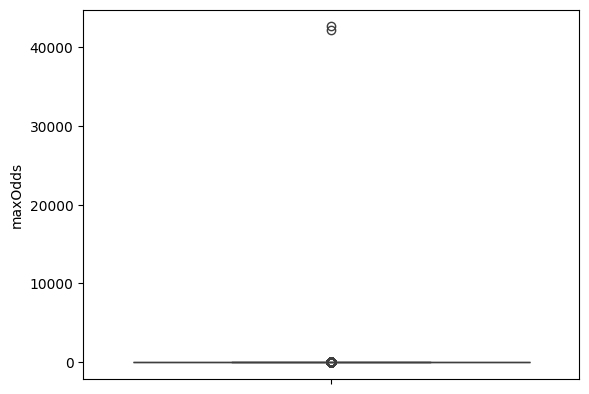

In [57]:
maxOdds = pd.concat([df['MaxA'], df['MaxB']], axis=0).rename('maxOdds')
sns.boxplot(data=maxOdds)
plt.show()

In [58]:
mask = (df['MaxA']>100) | (df['MaxB']>100)
df.loc[mask, ['MaxA']] = df.loc[mask].apply(lambda row: row['B365A'] if row['B365A']>row['AvgA'] else row['AvgA'], axis=1)
df.loc[mask, ['MaxB']] = df.loc[mask].apply(lambda row: row['B365B'] if row['B365B']>row['AvgB'] else row['AvgB'], axis=1)

# Volvemos a crear maxOdds
maxOdds = pd.concat([df['MaxA'], df['MaxB']], axis=0).rename('maxOdds')

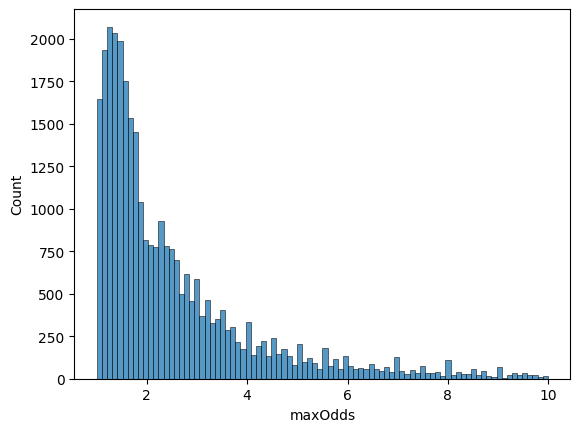

In [61]:
sns.histplot(maxOdds[maxOdds<10])
plt.show()

Variable Market Uncertainty: la mayoría de los partidos son bastante parejos

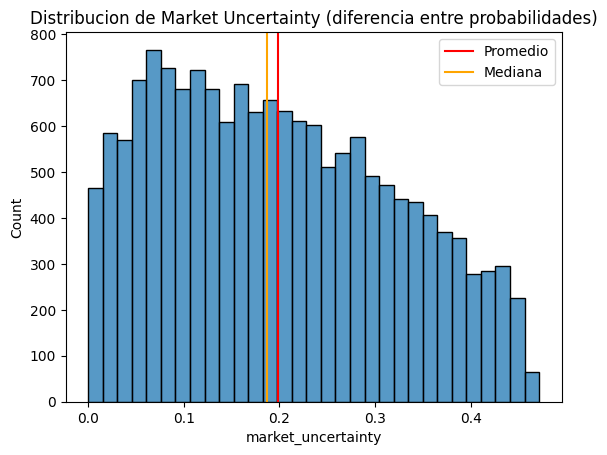

In [66]:
plt.title('Distribucion de Market Uncertainty (diferencia entre probabilidades)')
sns.histplot(df['market_uncertainty'])
plt.axvline(x=df['market_uncertainty'].mean(), color='red', label='Promedio')
plt.axvline(x=df['market_uncertainty'].median(), color='orange', label='Mediana')
plt.legend()
plt.show()

In [36]:
df_0 = pd.read_csv('https://raw.githubusercontent.com/ichiP245/my-next-soderling/refs/heads/main/Archivos/TenisCSV.csv')


In [39]:
max = pd.concat([df_0['MaxW'], df_0['MaxL']], axis=0)
avg = pd.concat([df_0['AvgW'], df_0['AvgL']], axis=0)

In [42]:
((max - avg) <0).sum()

np.int64(8)

In [44]:
df_0[((df_0['MaxW'] - df_0['AvgW']) < 0) | ((df_0['MaxL'] - df_0['AvgL']) < 0)]

,Unnamed: 0,ATP,Location,Tournament,Date,Series,Court,Surface,Round,Best of,Winner,Loser,WRank,LRank,WPts,LPts,W1,L1,W2,L2,W3,L3,W4,L4,W5,L5,Wsets,Lsets,Comment,B365W,B365L,PSW,PSL,MaxW,MaxL,AvgW,AvgL
1396,126,29.0,Paris,French Open,08/06/2025,Grand Slam,Outdoor,Clay,The Final,5.0,Alcaraz C.,Sinner J.,2.0,1.0,8850.0,10380.0,4.0,6.0,6.0,7.0,6.0,4.0,7.0,6.0,7.0,6.0,3.0,2.0,Completed,2.00,1.83,2.03,1.88,2.03,1.94,1.85,1.95
1513,116,52.0,New York,US Open,07/09/15,Grand Slam,Outdoor,Hard,4th Round,5.0,Wawrinka S.,Young D.,5.0,68.0,5710.0,730.0,6.0,4.0,1.0,6.0,6.0,3.0,6.0,4.0,NaN,NaN,3.0,1.0,Completed,1.11,6.50,1.14,6.92,1.15,7.00,1.12,7.06
1620,96,52.0,New York,US Open,02/09/16,Grand Slam,Outdoor,Hard,3rd Round,5.0,Tsonga J.W.,Anderson K.,11.0,35.0,2875.0,1275.0,6.0,3.0,6.0,4.0,7.0,6.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,1.44,2.75,1.47,2.94,1.48,3.05,1.42,3.82
4495,50,40.0,London,Wimbledon,04/07/17,Grand Slam,Outdoor,Grass,1st Round,5.0,Sock J.,Garin C.,18.0,220.0,2335.0,245.0,6.0,3.0,4.0,6.0,7.0,6.0,6.0,3.0,NaN,NaN,3.0,1.0,Completed,1.16,5.00,1.22,4.86,1.22,5.50,1.18,5.78
5760,24,17.0,New York,Western & Southern Financial Group Masters,24/08/2020,Masters 1000,Outdoor,Hard,2nd Round,3.0,Tsitsipas S.,Anderson K.,6.0,124.0,4745.0,445.0,6.0,1.0,6.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,Completed,1.22,4.00,1.31,4.60,1.31,3.85,1.25,3.95
10115,49,30.0,Rome,Internazionali BNL d'Italia,15/05/15,Masters 1000,Outdoor,Clay,Quarterfinals,3.0,Federer R.,Berdych T.,2.0,5.0,8645.0,5140.0,6.0,3.0,6.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,Completed,1.53,2.50,1.64,2.44,1.64,1.88,1.50,2.59
10392,51,20.0,Rome,Internazionali BNL d'Italia,20/09/2020,Masters 1000,Outdoor,Clay,Semifinals,3.0,Djokovic N.,Ruud C.,1.0,34.0,10860.0,1359.0,7.0,5.0,6.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,Completed,1.16,5.00,1.19,5.49,1.20,5.70,17.00,5.05
14517,2,48.0,Washington,Citi Open,03/08/15,ATP500,Outdoor,Hard,1st Round,3.0,Chung H.,Sela D.,77.0,125.0,638.0,427.0,6.0,2.0,6.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,Completed,2.00,1.72,2.09,1.81,1.83,1.84,2.02,1.76


In [45]:
df[((df['MaxA'] - df['AvgA']) < 0) | ((df['MaxB'] - df['AvgB']) < 0)]

,Location,Series,Court,Surface,Round,Best of,Fecha,playerA,playerB,rankA,rankB,PtsA,PtsB,B365A,B365B,MaxA,MaxB,AvgA,AvgB,A1,B1,A2,B2,A3,B3,A4,B4,A5,B5,setsA,setsB,target,setsPartido,B365BookmakersMargin,B365ProbA,B365ProbB,ProbAvgA,ProbAvgB,ProbMaxA,ProbMaxB,market_uncertainty,SpreadOddsA,SpreadOddsB,AvgOddsDiff,logit_oddsA,logit_oddsB,rankDiff,ptsDiff,winrate_5_A,winrate_10_A,wins_before_A,win_pct_before_A,sets_5d_A,sets_30d_A,partidos_365d_A,dias_ultimo_partido_A,racha_victorias_A,winrate_5_B,winrate_10_B,wins_before_B,win_pct_before_B,sets_5d_B,sets_30d_B,partidos_365d_B,dias_ultimo_partido_B,racha_victorias_B,diff_winrate_5,diff_winrate_10,diff_win_pct_before,diff_sets_5d,diff_sets_30d,diff_dias_ultimo_partido,diff_partidos_365d,h2h_matches_previous,date,temperature_2m_mean,apparent_temperature_mean,precipitation_sum,rain_sum,wind_speed_10m_max,wind_gusts_10m_max,wind_gusts_10m_mean,wind_speed_10m_mean,relative_humidity_2m_mean,relative_humidity_2m_max,relative_humidity_2m_min,soil_temperature_0_to_100cm_mean,soil_moisture_0_to_100cm_mean,wind_gusts_10m_min,wind_speed_10m_min,Ciudad
703,Rome,Masters 1000,Outdoor,Clay,Quarterfinals,3.0,2015-05-15,Berdych T.,Federer R.,5.0,2.0,5140.0,8645.0,2.50,1.53,1.88,1.64,2.59,1.50,3.0,6.0,3.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0,2.0,0.053595,0.379653,0.620347,0.366748,0.633252,0.465909,0.534091,0.133252,0.099161,0.099161,-0.266504,-0.546193,0.546193,3.0,-3505.0,0.800000,0.800000,32.0,0.800000,5.0,23.0,40,1.0,2,0.6,0.7,15.0,0.789474,4.0,11.0,19,1.0,2,0.200000,0.100000,0.010526,1.0,12.0,0.0,21,1,2015-05-15,20.031502,18.805014,0.000000,0.000000,25.338476,52.560000,31.635000,15.250350,65.345680,81.691950,47.956104,17.630190,0.291545,16.560000,8.350138,Rome
1029,Washington,ATP500,Outdoor,Hard,1st Round,3.0,2015-08-03,Chung H.,Sela D.,77.0,125.0,638.0,427.0,2.00,1.72,1.83,1.84,2.02,1.76,6.0,2.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1,2.0,0.081395,0.462366,0.537634,0.465608,0.534392,0.501362,0.498638,0.034392,0.035754,0.035754,-0.068783,-0.137784,0.137784,-48.0,211.0,0.333333,0.333333,1.0,0.333333,0.0,0.0,3,35.0,0,0.4,0.5,3.0,0.500000,0.0,0.0,6,35.0,0,-0.066667,-0.166667,-0.166667,0.0,0.0,0.0,-3,0,2015-08-03,26.544168,27.618864,0.000000,0.000000,14.386494,38.519997,25.094997,10.256947,56.699314,83.936424,33.787895,23.731901,0.365844,15.119999,7.289445,Washington
1299,New York,Grand Slam,Outdoor,Hard,4th Round,5.0,2015-09-07,Wawrinka S.,Young D.,5.0,68.0,5710.0,730.0,1.11,6.50,1.15,7.00,1.12,7.06,6.0,4.0,1.0,6.0,6.0,3.0,6.0,4.0,0.0,0.0,3.0,1.0,1,4.0,0.054747,0.854139,0.145861,0.863081,0.136919,0.858896,0.141104,0.363081,-0.004185,-0.004185,0.726161,1.841116,-1.841116,-63.0,4980.0,0.800000,0.700000,32.0,0.780488,6.0,19.0,41,2.0,3,0.8,0.6,10.0,0.476190,9.0,20.0,21,2.0,3,0.000000,0.100000,0.304297,-3.0,-1.0,0.0,20,0,2015-09-07,24.617416,25.717218,0.000000,0.000000,13.246826,24.119999,20.640000,10.035094,64.496030,91.532370,37.268890,23.713125,0.236536,18.359999,5.959060,New York
2754,New York,Grand Slam,Outdoor,Hard,3rd Round,5.0,2016-09-02,Tsonga J.W.,Anderson K.,11.0,35.0,2875.0,1275.0,1.44,2.75,1.48,3.05,1.42,3.82,6.0,3.0,6.0,4.0,7.0,6.0,0.0,0.0,0.0,0.0,3.0,0.0,1,3.0,0.058081,0.656325,0.343675,0.729008,0.270992,0.673289,0.326711,0.229008,-0.055718,-0.055718,0.458015,0.989594,-0.989594,-24.0,1600.0,0.600000,0.700000,47.0,0.671429,7.0,11.0,43,2.0,2,0.8,0.5,34.0,0.586207,6.0,11.0,28,2.0,2,-0.200000,0.200000,0.085222,1.0,0.0,0.0,15,1,2016-09-02,22.129915,21.632235,0.000000,0.000000,16.299694,30.960001,24.630000,11.810907,58.749527,73.089610,38.445150,23.947561,0.247944,15.119999,6.569383,New York
3936,London,Grand Slam,Outdoor,Grass,1st Round,5.0,2017-07-04,Garin C.,Sock J.,220.0,18.0,245.0,2335.0,5.00,1.16,5.50,1.22,5.78,1.18,3.0,6.0,6.0,4.0,6.0,7.0,3.0,6.0,0.0,0.0,1.0,3.0,0,4.0,0.062069,0.188312,0.811688,0.169540,0.830460,0.181548,0.818452,0.330460,0.012007,0.012007,-0.660920,-1.588889,1.588889,202.0,-2090.0,NaN,NaN,0.0,NaN,0.0,0.0,0,NaN,0,0.4,0.5,55.0,0.611111,0.0,0.0,37,36.0,0,NaN,NaN,NaN,0

Variable Spread Odds: notamos una inconsistencia que nos genera que tengamos que dropear columnas

- El spread odds debería ser siempre positivo ya que es la diferencia entre la probabilidad máxima que encontramos para cada jugador de ganar y la probabilidad media entre todas las cuotas del mercado.
- Sin embargo, fue incorrecto calcular la probabilidad de maxOdds para cada jugador porque si consideramos que cuando el jugador A tiene unas odds que son las máxima de él para el mercado, el otro jugador no va a tener también sus maxOdds. En pocas palabras, el cálculo de probabilidad implícita en las cuotas fue metodológicamente erróneo. Por eso, sacamos las columnas de SpreadOddsA y SpreadOddsB
- Podemos dejar las columnas de ProbMaxA y ProbMaxB pero las interpretaciones serían diferentes: dado que tenemos la mejor cuota de mercado para cada jugador estaríamos calculando la probabilidad para cada jugador entre esas 2 cuotas -> que no son de la misma casa de apuestas entonces es un valor más relativo
- Esto nos da pie también a calcular las diferencias entre las probabilidades de que gane cada jugador, que es una variable que no habíamos creado hasta el momento

In [84]:
((df['ProbMaxA'] - df['ProbAvgA']) < 0).sum(), ((df['ProbMaxB'] - df['ProbAvgB']) < 0).sum(),

(np.int64(7965), np.int64(8078))

In [87]:
df[(df['MaxA'] < df['AvgA']) | (df['MaxB'] < df['AvgB'])]

,Location,Series,Court,Surface,Round,Best of,Fecha,playerA,playerB,rankA,rankB,PtsA,PtsB,B365A,B365B,MaxA,MaxB,AvgA,AvgB,A1,B1,A2,B2,A3,B3,A4,B4,A5,B5,setsA,setsB,target,setsPartido,B365BookmakersMargin,B365ProbA,B365ProbB,ProbAvgA,ProbAvgB,ProbMaxA,ProbMaxB,market_uncertainty,SpreadOddsA,SpreadOddsB,AvgOddsDiff,logit_oddsA,logit_oddsB,rankDiff,ptsDiff,winrate_5_A,winrate_10_A,wins_before_A,win_pct_before_A,sets_5d_A,sets_30d_A,partidos_365d_A,dias_ultimo_partido_A,racha_victorias_A,winrate_5_B,winrate_10_B,wins_before_B,win_pct_before_B,sets_5d_B,sets_30d_B,partidos_365d_B,dias_ultimo_partido_B,racha_victorias_B,diff_winrate_5,diff_winrate_10,diff_win_pct_before,diff_sets_5d,diff_sets_30d,diff_dias_ultimo_partido,diff_partidos_365d,h2h_matches_previous
703,Rome,Masters 1000,Outdoor,Clay,Quarterfinals,3.0,2015-05-15,Berdych T.,Federer R.,5.0,2.0,5140.0,8645.0,2.50,1.53,1.88,1.64,2.59,1.50,3.0,6.0,3.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0,2.0,0.053595,0.379653,0.620347,0.366748,0.633252,0.465909,0.534091,0.133252,0.099161,0.099161,-0.266504,-0.546193,0.546193,3.0,-3505.0,0.800000,0.800000,32.0,0.800000,5.0,23.0,40,1.0,2,0.6,0.7,15.0,0.789474,4.0,11.0,19,1.0,2,0.200000,0.100000,0.010526,1.0,12.0,0.0,21,1
1029,Washington,ATP500,Outdoor,Hard,1st Round,3.0,2015-08-03,Chung H.,Sela D.,77.0,125.0,638.0,427.0,2.00,1.72,1.83,1.84,2.02,1.76,6.0,2.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1,2.0,0.081395,0.462366,0.537634,0.465608,0.534392,0.501362,0.498638,0.034392,0.035754,0.035754,-0.068783,-0.137784,0.137784,-48.0,211.0,0.333333,0.333333,1.0,0.333333,0.0,0.0,3,35.0,0,0.4,0.5,3.0,0.500000,0.0,0.0,6,35.0,0,-0.066667,-0.166667,-0.166667,0.0,0.0,0.0,-3,0
1299,New York,Grand Slam,Outdoor,Hard,4th Round,5.0,2015-09-07,Wawrinka S.,Young D.,5.0,68.0,5710.0,730.0,1.11,6.50,1.15,7.00,1.12,7.06,6.0,4.0,1.0,6.0,6.0,3.0,6.0,4.0,0.0,0.0,3.0,1.0,1,4.0,0.054747,0.854139,0.145861,0.863081,0.136919,0.858896,0.141104,0.363081,-0.004185,-0.004185,0.726161,1.841116,-1.841116,-63.0,4980.0,0.800000,0.700000,32.0,0.780488,6.0,19.0,41,2.0,3,0.8,0.6,10.0,0.476190,9.0,20.0,21,2.0,3,0.000000,0.100000,0.304297,-3.0,-1.0,0.0,20,0
2754,New York,Grand Slam,Outdoor,Hard,3rd Round,5.0,2016-09-02,Tsonga J.W.,Anderson K.,11.0,35.0,2875.0,1275.0,1.44,2.75,1.48,3.05,1.42,3.82,6.0,3.0,6.0,4.0,7.0,6.0,0.0,0.0,0.0,0.0,3.0,0.0,1,3.0,0.058081,0.656325,0.343675,0.729008,0.270992,0.673289,0.326711,0.229008,-0.055718,-0.055718,0.458015,0.989594,-0.989594,-24.0,1600.0,0.600000,0.700000,47.0,0.671429,7.0,11.0,43,2.0,2,0.8,0.5,34.0,0.586207,6.0,11.0,28,2.0,2,-0.200000,0.200000,0.085222,1.0,0.0,0.0,15,1
3936,London,Grand Slam,Outdoor,Grass,1st Round,5.0,2017-07-04,Garin C.,Sock J.,220.0,18.0,245.0,2335.0,5.00,1.16,5.50,1.22,5.78,1.18,3.0,6.0,6.0,4.0,6.0,7.0,3.0,6.0,0.0,0.0,1.0,3.0,0,4.0,0.062069,0.188312,0.811688,0.169540,0.830460,0.181548,0.818452,0.330460,0.012007,0.012007,-0.660920,-1.588889,1.588889,202.0,-2090.0,NaN,NaN,0.0,NaN,0.0,0.0,0,NaN,0,0.4,0.5,55.0,0.611111,0.0,0.0,37,36.0,0,NaN,NaN,NaN,0.0,0.0,NaN,-37,0
7883,New York,Masters 1000,Outdoor,Hard,2nd Round,3.0,2020-08-24,Tsitsipas S.,Anderson K.,6.0,124.0,4745.0,445.0,1.22,4.00,1.31,3.85,1.25,3.95,6.0,1.0,6.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1,2.0,0.069672,0.766284,0.233716,0.759615,0.240385,0.746124,0.253876,0.259615,-0.013491,-0.013491,0.519231,1.150572,-1.150572,-118.0,4300.0,0.800000,0.700000,73.0,0.613445,0.0,0.0,27,177.0,0,0.6,0.7,104.0,0.638037,3.0,3.0,3,2.0,1,0.200000,0.000000,-0.024591,-3.0,-3.0,175.0,24,1
8084,Rome,Masters 1000,Outdoor,Clay,Semifinals,3.0,2020-09-20,Djokovic N.,Ruud C.,1.0,34.0,10860.0,1359.0,1.16,5.00,1.20,5.70,17.00,5.05,7.0,5.0,6.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1,2.0,0.062069,0.811688,0.188312,0.229025,0.770975,0.826087,0.173913,0.270975,0.597062,0.597062,-0.541950,-1.213825,1.213825,-33.0,9501.0,0.800000,0.900000,280.0,0.877743,7.0,29.0,37,1.0,3,0.8,0.6,20.0,0.444444,7.0,22.0,11,1.0,4,0.000000,0.300000,0.433299,0.0,7.0,0.0,26,0
12069,Halle,ATP500,Outdoor,Grass,1st Round,3.0,2023-06-20

In [85]:
df.drop(columns=['SpreadOddsA', 'SpreadOddsB'])

,Location,Series,Court,Surface,Round,Best of,Fecha,playerA,playerB,rankA,rankB,PtsA,PtsB,B365A,B365B,MaxA,MaxB,AvgA,AvgB,A1,B1,A2,B2,A3,B3,A4,B4,A5,B5,setsA,setsB,target,setsPartido,B365BookmakersMargin,B365ProbA,B365ProbB,ProbAvgA,ProbAvgB,ProbMaxA,ProbMaxB,market_uncertainty,AvgOddsDiff,logit_oddsA,logit_oddsB,rankDiff,ptsDiff,winrate_5_A,winrate_10_A,wins_before_A,win_pct_before_A,sets_5d_A,sets_30d_A,partidos_365d_A,dias_ultimo_partido_A,racha_victorias_A,winrate_5_B,winrate_10_B,wins_before_B,win_pct_before_B,sets_5d_B,sets_30d_B,partidos_365d_B,dias_ultimo_partido_B,racha_victorias_B,diff_winrate_5,diff_winrate_10,diff_win_pct_before,diff_sets_5d,diff_sets_30d,diff_dias_ultimo_partido,diff_partidos_365d,h2h_matches_previous
0,Doha,ATP250,Outdoor,Hard,1st Round,3.0,2015-01-05,Andujar P.,Gasquet R.,41.0,26.0,950.0,1350.0,4.33,1.20,4.84,1.26,4.15,1.21,3.0,6.0,5.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0,2.0,0.064280,0.216998,0.783002,0.225746,0.774254,0.206557,0.793443,0.274254,-0.548507,-1.232488,1.232488,15.0,-400.0,NaN,NaN,0.0,NaN,0.0,0.0,0,NaN,0,NaN,NaN,0.0,NaN,0.0,0.0,0,NaN,0,NaN,NaN,NaN,0.0,0.0,NaN,0,0
1,Doha,ATP250,Outdoor,Hard,1st Round,3.0,2015-01-05,Dodig I.,Safwat M.,89.0,289.0,575.0,168.0,1.16,5.00,1.19,5.84,1.16,5.05,6.0,3.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1,2.0,0.062069,0.811688,0.188312,0.813205,0.186795,0.830725,0.169275,0.313205,0.626409,1.470968,-1.470968,-200.0,407.0,NaN,NaN,0.0,NaN,0.0,0.0,0,NaN,0,NaN,NaN,0.0,NaN,0.0,0.0,0,NaN,0,NaN,NaN,NaN,0.0,0.0,NaN,0,0
2,Doha,ATP250,Outdoor,Hard,1st Round,3.0,2015-01-05,Verdasco F.,Gabashvili T.,33.0,66.0,1135.0,730.0,1.40,2.75,1.47,3.09,1.41,2.81,4.0,6.0,6.0,3.0,7.0,6.0,0.0,0.0,0.0,0.0,2.0,1.0,1,3.0,0.077922,0.662651,0.337349,0.665877,0.334123,0.677632,0.322368,0.165877,0.331754,0.689595,-0.689595,-33.0,405.0,NaN,NaN,0.0,NaN,0.0,0.0,0,NaN,0,NaN,NaN,0.0,NaN,0.0,0.0,0,NaN,0,NaN,NaN,NaN,0.0,0.0,NaN,0,0
3,Doha,ATP250,Outdoor,Hard,1st Round,3.0,2015-01-05,Karlovic I.,Rosol L.,27.0,30.0,1320.0,1210.0,1.44,2.62,1.53,2.75,1.49,2.54,7.0,6.0,6.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1,2.0,0.076124,0.645320,0.354680,0.630273,0.369727,0.642523,0.357477,0.130273,0.260546,0.533388,-0.533388,-3.0,110.0,NaN,NaN,0.0,NaN,0.0,0.0,0,NaN,0,NaN,NaN,0.0,NaN,0.0,0.0,0,NaN,0,NaN,NaN,NaN,0.0,0.0,NaN,0,0
4,Doha,ATP250,Outdoor,Hard,1st Round,3.0,2015-01-05,Becker B.,Bolelli S.,40.0,52.0,973.0,810.0,1.61,2.20,1.76,2.25,1.67,2.15,3.0,6.0,6.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0,2.0,0.075663,0.577428,0.422572,0.562827,0.437173,0.561097,0.438903,0.062827,0.125654,0.252644,-0.252644,-12.0,163.0,NaN,NaN,0.0,NaN,0.0,0.0,0,NaN,0,NaN,NaN,0.0,NaN,0.0,0.0,0,NaN,0,NaN,NaN,NaN,0.0,0.0,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16056,Paris,Masters 1000,Indoor,Hard,Quarterfinals,3.0,2025-10-31,Shelton B.,Sinner J.,7.0,2.0,3820.0,10500.0,5.00,1.17,5.25,1.17,5.11,1.16,3.0,6.0,3.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0,2.0,0.054701,0.189627,0.810373,0.185008,0.814992,0.182243,0.817757,0.314992,-0.629984,-1.482779,1.482779,5.0,-6680.0,0.6,0.6,87.0,0.635036,4.0,11.0,45,1.0,2,1.0,0.9,240.0,0.789474,7.0,21.0,56,1.0,7,-0.4,-0.3,-0.154437,-3.0,-10.0,0.0,-11,7
16057,Paris,Masters 1000,Indoor,Hard,Quarterfinals,3.0,2025-10-31,Zverev A.,Medvedev D.,3.0,13.0,6160.0,2810.0,2.10,1.73,2.10,1.80,2.04,1.75,2.0,6.0,6.0,3.0,7.0,6.0,0.0,0.0,0.0,0.0,2.0,1.0,1,3.0,0.054225,0.451697,0.548303,0.461741,0.538259,0.461538,0.538462,0.038259,-0.076517,-0.153334,0.153334,-10.0,3350.0,0.8,0.7,397.0,0.714029,8.0,20.0,65,1.0,2,0.8,0.8,288.0,0.711111,5.0,22.0,49,1.0,3,0.0,-0.1,0.002918,3.0,-2.0,0.0,16,13
16058,Paris,Masters 1000,Indoor,Hard,Semifinals,3.0,2025-11-01,Bublik A.,Auger-Aliassime F.,16.0,10.0,2520.0,3195.0,1.91,1.91,1.95,1.95,1.88,1.90,6.0,7.0,4.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [24]:
df.select_dtypes(include='number').drop(columns=['Best of'])

,rankA,rankB,PtsA,PtsB,B365A,B365B,MaxA,MaxB,AvgA,AvgB,A1,B1,A2,B2,A3,B3,A4,B4,A5,B5,setsA,setsB,target,setsPartido,B365BookmakersMargin,B365ProbA,B365ProbB,ProbAvgA,ProbAvgB,ProbMaxA,ProbMaxB,market_uncertainty,SpreadOddsA,SpreadOddsB,AvgOddsDiff,logit_oddsA,logit_oddsB,rankDiff,ptsDiff,winrate_5_A,winrate_10_A,wins_before_A,win_pct_before_A,sets_5d_A,sets_30d_A,partidos_365d_A,dias_ultimo_partido_A,racha_victorias_A,winrate_5_B,winrate_10_B,wins_before_B,win_pct_before_B,sets_5d_B,sets_30d_B,partidos_365d_B,dias_ultimo_partido_B,racha_victorias_B,diff_winrate_5,diff_winrate_10,diff_win_pct_before,diff_sets_5d,diff_sets_30d,diff_dias_ultimo_partido,diff_partidos_365d,h2h_matches_previous
0,41.0,26.0,950.0,1350.0,4.33,1.20,4.84,1.26,4.15,1.21,3.0,6.0,5.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0,2.0,0.064280,0.216998,0.783002,0.225746,0.774254,0.206557,0.793443,0.274254,-0.019189,-0.019189,-0.548507,-1.232488,1.232488,15.0,-400.0,NaN,NaN,0.0,NaN,0.0,0.0,0,NaN,0,NaN,NaN,0.0,NaN,0.0,0.0,0,NaN,0,NaN,NaN,NaN,0.0,0.0,NaN,0,0
1,89.0,289.0,575.0,168.0,1.16,5.00,1.19,5.84,1.16,5.05,6.0,3.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1,2.0,0.062069,0.811688,0.188312,0.813205,0.186795,0.830725,0.169275,0.313205,0.017521,0.017521,0.626409,1.470968,-1.470968,-200.0,407.0,NaN,NaN,0.0,NaN,0.0,0.0,0,NaN,0,NaN,NaN,0.0,NaN,0.0,0.0,0,NaN,0,NaN,NaN,NaN,0.0,0.0,NaN,0,0
2,33.0,66.0,1135.0,730.0,1.40,2.75,1.47,3.09,1.41,2.81,4.0,6.0,6.0,3.0,7.0,6.0,0.0,0.0,0.0,0.0,2.0,1.0,1,3.0,0.077922,0.662651,0.337349,0.665877,0.334123,0.677632,0.322368,0.165877,0.011755,0.011755,0.331754,0.689595,-0.689595,-33.0,405.0,NaN,NaN,0.0,NaN,0.0,0.0,0,NaN,0,NaN,NaN,0.0,NaN,0.0,0.0,0,NaN,0,NaN,NaN,NaN,0.0,0.0,NaN,0,0
3,27.0,30.0,1320.0,1210.0,1.44,2.62,1.53,2.75,1.49,2.54,7.0,6.0,6.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1,2.0,0.076124,0.645320,0.354680,0.630273,0.369727,0.642523,0.357477,0.130273,0.012250,0.012250,0.260546,0.533388,-0.533388,-3.0,110.0,NaN,NaN,0.0,NaN,0.0,0.0,0,NaN,0,NaN,NaN,0.0,NaN,0.0,0.0,0,NaN,0,NaN,NaN,NaN,0.0,0.0,NaN,0,0
4,40.0,52.0,973.0,810.0,1.61,2.20,1.76,2.25,1.67,2.15,3.0,6.0,6.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0,2.0,0.075663,0.577428,0.422572,0.562827,0.437173,0.561097,0.438903,0.062827,-0.001730,-0.001730,0.125654,0.252644,-0.252644,-12.0,163.0,NaN,NaN,0.0,NaN,0.0,0.0,0,NaN,0,NaN,NaN,0.0,NaN,0.0,0.0,0,NaN,0,NaN,NaN,NaN,0.0,0.0,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16056,7.0,2.0,3820.0,10500.0,5.00,1.17,5.25,1.17,5.11,1.16,3.0,6.0,3.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0,2.0,0.054701,0.189627,0.810373,0.185008,0.814992,0.182243,0.817757,0.314992,-0.002765,-0.002765,-0.629984,-1.482779,1.482779,5.0,-6680.0,0.6,0.6,87.0,0.635036,4.0,11.0,45,1.0,2,1.0,0.9,240.0,0.789474,7.0,21.0,56,1.0,7,-0.4,-0.3,-0.154437,-3.0,-10.0,0.0,-11,7
16057,3.0,13.0,6160.0,2810.0,2.10,1.73,2.10,1.80,2.04,1.75,2.0,6.0,6.0,3.0,7.0,6.0,0.0,0.0,0.0,0.0,2.0,1.0,1,3.0,0.054225,0.451697,0.548303,0.461741,0.538259,0.461538,0.538462,0.038259,-0.000203,-0.000203,-0.076517,-0.153334,0.153334,-10.0,3350.0,0.8,0.7,397.0,0.714029,8.0,20.0,65,1.0,2,0.8,0.8,288.0,0.711111,5.0,22.0,49,1.0,3,0.0,-0.1,0.002918,3.0,-2.0,0.0,16,13
16058,16.0,10.0,2520.0,3195.0,1.91,1.91,1.95,1.95,1.88,1.90,6.0,7.0,4.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0,2.0,0.047120,0.500000,0.500000,0.502646,0.497354,0.500000,0.500000,0.002646,-0.002646,-0.002646,0.005291,0.010582,-0.010582,6.0,-675.0,0.8,0.6,89.0,0.473404,9.0,18.0,39,1.0,4,0.8,0.8,170.0,0.600707,11.0,24.0,48,1.0,4,0.0,-0.2,-0.127302,-2.0,-6.0,0.0,-9,4
16059,3.0,2.0,6160.0,10500.0,6.00,1.13,6.00,1.16,5.35,1.15,0.0,6.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0,2.0,0.051622,0.158485,0.841515,0.176923,0.823077,0.162011,0.837989,0.323077,-0.014912,-0.014912,-0.646154,-1.537335,1.537335,1.0,-4340.0,0.8,0.8,398.0,0.714542,8.0,23.0,6